In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

from extrinsic_calibration import (
    show, detect_green_squares, estimate_square_poses, draw_poses
)

# Fix matplotlib/IPython compatibility issue
import matplotlib
if not hasattr(matplotlib.rcParams, '_get'):
    matplotlib.rcParams._get = matplotlib.rcParams.get

In [3]:
square_size = 0.10  # meters

cameraMatrix = np.array([
    [914.0151876932167, 0.0, 640.0],  # k matrix in /camera_info
    [0.0, 914.0151876932167, 360.0],
    [0.0, 0.0, 1.0]
])
distCoeffs = np.array([0, 0, 0, 0, 0], dtype=np.float32)  # d matrix in /camera_info

In [4]:
# Load image
img = cv2.imread("../../ressources/watchtower_view.png")

# Detect green squares
squares, squares_cnts = detect_green_squares(img)
print(f"✓ {len(squares)} square(s) detected")

# Estimate pose for each detected square
poses = estimate_square_poses(
    squares=squares,
    square_size=square_size,
    camera_matrix=cameraMatrix,
    dist_coeffs=distCoeffs,
)

✓ 4 square(s) detected



=== Square 0 ===
Position (tvec): [ 0.0845435  -0.04819328  0.87013471]
Rotation (rvec): [ 2.27594903 -0.1021277   0.20866176]
Distance: 0.876 m

=== Square 1 ===
Position (tvec): [-0.26368421 -0.04738802  0.79671719]
Rotation (rvec): [ 2.25807645 -0.0937708   0.20883292]
Distance: 0.841 m

=== Square 2 ===
Position (tvec): [ 0.0843215  -0.27631746  1.14102468]
Rotation (rvec): [ 2.25684696 -0.09000211  0.19743692]
Distance: 1.177 m

=== Square 3 ===
Position (tvec): [-0.31217757 -0.27440677  1.05978412]
Rotation (rvec): [ 2.25333805 -0.09496114  0.20278644]
Distance: 1.138 m

✓ 4 pose(s) estimated


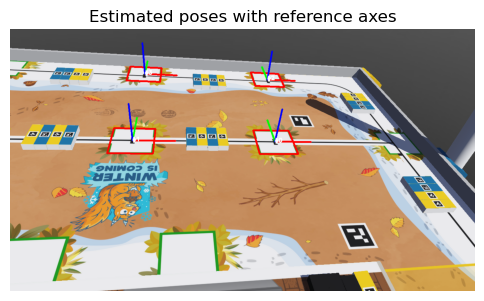

In [ ]:
# Draw squares with centers and orientations
result_img = img.copy()
for sq_cnt in squares_cnts:
    cv2.drawContours(result_img, [sq_cnt], -1, (0, 0, 255), 3)

for pose in poses:
    print(f"\n=== Square {pose['id']} ===")
    print(f"Position (tvec): {pose['tvec'].flatten()}")
    print(f"Rotation (rvec): {pose['rvec'].flatten()}")
    print(f"Distance: {np.linalg.norm(pose['tvec']):.3f} m")

print(f"\n✓ {len(poses)} pose(s) estimated")

# Display reference axes for each detected square
result_img = draw_poses(result_img, poses, cameraMatrix, distCoeffs)

show("Estimated poses with reference axes", result_img)